# 05-市场估值分析：判断当前该买还是该等

**学习目标：**
- 看懂 PE 估值分位，判断指数是贵还是便宜
- 掌握股债性价比模型，评估大类资产配置方向
- 会看估值温度计，感知市场情绪
- 综合多个信号，制定自己当前的买卖计划

**前置知识：** 你已经会用 fetch_index.py 查指数估值，了解 PE 基本概念

> 温馨提示：估值分析不能预测短期涨跌，但能告诉你当前位置是山顶还是山谷。便宜时不代表会立刻涨，贵时不代表会立刻跌。


## 第1步：导入工具


In [1]:
import sys, os
sys.path.insert(0, os.path.join(os.getcwd(), '..') if 'notebooks' in os.getcwd() else '.')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from datetime import date, timedelta
import warnings
warnings.filterwarnings('ignore')

# 中文字体
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 数据与工具
from scripts.data.fetch_index import (
    INDEX_MAP, PE_HISTORY, _estimate_pe_percentile,
    _get_index_valuation, show_valuation,
)
from scripts.data.client import _ensure_ak
import akshare as ak

print('[OK] 全部导入成功')


[OK] 全部导入成功


## 第2步：获取主要指数当前估值

用 akshare 获取所有指数的当前 PE 值，然后和我们记录的历史极值对比。


In [2]:
# 获取指数估值数据
_ensure_ak()
df = ak.index_value_hist_funddb()
print(f'数据量: {len(df)} 条')
print(f'日期范围: {df["日期"].min()} ~ {df["日期"].max()}')
df.head()


AttributeError: module 'akshare' has no attribute 'index_value_hist_funddb'

In [3]:
# 提取我们关注的指数当前PE，并计算分位
valuation_rows = []

for index_code, info in INDEX_MAP.items():
    latest = df[df['指数代码'] == index_code]
    if latest.empty:
        continue
    
    pe_val = float(latest['市盈率'].values[0])
    pb_val = float(latest.get('市净率', pd.Series([None])).values[0]) if '市净率' in df.columns else None
    
    history = PE_HISTORY.get(index_code, {})
    if history:
        pct = _estimate_pe_percentile(pe_val, history)
        level = '低估' if pct < 30 else ('高估' if pct > 70 else '合理')
    else:
        pct = None
        level = '?'
    
    row = {
        '指数': info['name'],
        '代码': index_code,
        '当前PE': round(pe_val, 2),
        '历史最低': history.get('min', '?'),
        '历史中位': history.get('median', '?'),
        '历史最高': history.get('max', '?'),
        '分位(%)': pct,
        '状态': level,
    }
    if pb_val is not None:
        row['PB'] = round(pb_val, 2)
    valuation_rows.append(row)

val_df = pd.DataFrame(valuation_rows)
val_df.sort_values('分位(%)', ignore_index=True)


NameError: name 'df' is not defined

### 看不懂？看这个：

| PE分位 | 含义 | 对应的操作 |
|--------|------|-----------|
| < 30% | 比历史上70%的时间便宜 — **低估** | 可以考虑加仓/加大定投 |
| 30-70% | 估值在中间地带 — **合理** | 正常定投 |
| > 70% | 比历史上70%的时间贵 — **高估** | 减少定投或观望 |


## 第3步：估值温度计可视化

用一张图把所有指数的估值位置标出来，一目了然。


NameError: name 'val_df' is not defined

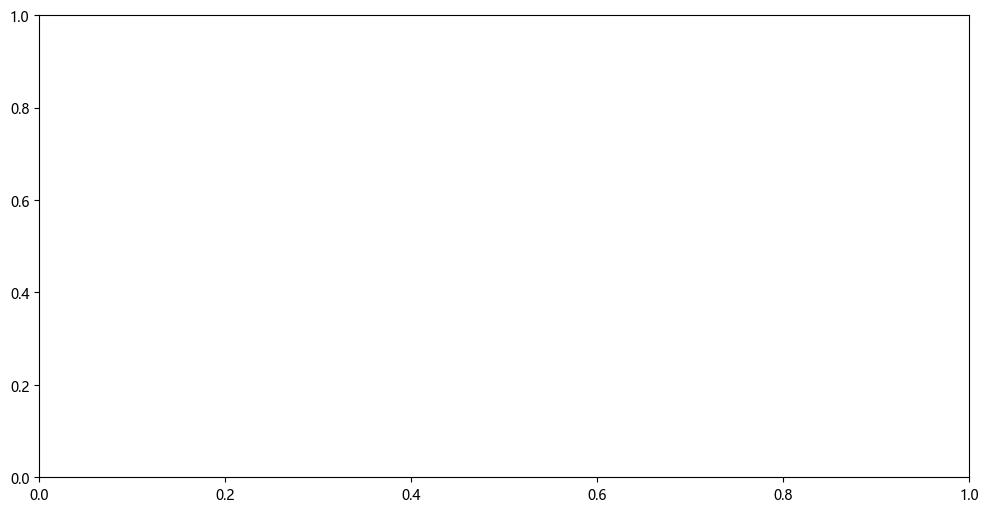

In [4]:
fig, ax = plt.subplots(figsize=(12, 6))

indices = val_df['指数'].tolist()
current_pcts = val_df['分位(%)'].tolist()
current_pes = val_df['当前PE'].tolist()
median_pes = val_df['历史中位'].tolist()

# 颜色映射：低估→绿色，合理→黄色，高估→红色
colors = []
for p in current_pcts:
    if p < 30:
        colors.append('#22c55e')  # 绿
    elif p > 70:
        colors.append('#ef4444')  # 红
    else:
        colors.append('#eab308')  # 黄

# 横向条形图
y_pos = range(len(indices))
ax.barh(y_pos, current_pcts, color=colors, alpha=0.8, height=0.5)

# 标注PE值
for i, (pct, pe, median) in enumerate(zip(current_pcts, current_pes, median_pes)):
    label = f'PE={pe} (中位={median})'
    ax.text(max(pct + 1, 1), i, label, va='center', fontsize=10, color='#333')

# 分区着色
ax.axvspan(0, 30, alpha=0.06, color='green', label='低估区')
ax.axvspan(30, 70, alpha=0.06, color='yellow', label='合理区')
ax.axvspan(70, 100, alpha=0.06, color='red', label='高估区')

ax.set_yticks(list(y_pos))
ax.set_yticklabels(indices, fontsize=12)
ax.set_xlabel('PE 估值分位 (%)', fontsize=12)
ax.set_title('A股主要指数 PE 估值温度计', fontsize=16, fontweight='bold')
ax.set_xlim(0, 105)
ax.legend(loc='lower right', fontsize=10)
ax.invert_yaxis()

plt.tight_layout()
plt.show()


## 第4步：股债性价比模型 (Fed Model)

核心思想：**买股票还是买债券，看谁的性价比更高。**

- 股票收益率 = 1 / PE（比如 PE=15，股票收益率=6.67%）
- 债券收益率 = 10年期国债收益率（约 2.6-3.5%）
- **股债价差 = 股票收益率 - 债券收益率**

价差越大 → 股票相对越便宜 → 应该多配股票
价差越小/负值 → 股票相对越贵 → 应该多配债券


In [ ]:
# 获取10年期国债收益率
try:
    bond_df = ak.bond_china_yield(start_date='2020-01-01')
    if bond_df is not None and not bond_df.empty:
        latest_bond_yield = float(bond_df['中国国债收益率10年'].iloc[-1])
    else:
        latest_bond_yield = 2.8  # 默认值
except Exception:
    # 如果获取失败，使用近似值
    latest_bond_yield = 2.8

print(f'10年期国债收益率: {latest_bond_yield}%')

# 计算各指数的股债价差
spread_rows = []
for _, row in val_df.iterrows():
    pe = row['当前PE']
    equity_yield = (1 / pe) * 100  # 股票收益率(%)
    spread = equity_yield - latest_bond_yield
    spread_rows.append({
        '指数': row['指数'],
        'PE': pe,
        '股票收益率(%)': round(equity_yield, 2),
        '债券收益率(%)': round(latest_bond_yield, 2),
        '股债价差(%)': round(spread, 2),
        '建议': '多配股票' if spread > 0.5 else ('多配债券' if spread < -0.5 else '均衡配置'),
    })

spread_df = pd.DataFrame(spread_rows)
spread_df


### 股债价差怎么用？

| 股债价差 | 含义 | 操作 |
|---------|------|------|
| > 0.5% | 股票更划算 | 增加股票基金配置 |
| -0.5% ~ 0.5% | 两者差不多 | 维持当前配置 |
| < -0.5% | 债券更划算 | 增加债券基金配置 |

> 历史上，沪深300股债价差在 -1% ~ 4% 之间波动。>2% 时通常是股票的好买点。


## 第5步：查看历史PE走势

看看沪深300 PE 在最近几年的变化，找到当前在历史中的位置。


In [ ]:
index_code = '000300'
prefix = 'sh' if index_code.startswith('000') else 'sz'

try:
    daily_df = ak.stock_zh_index_daily_em(symbol=f'{prefix}{index_code}')
    daily_df['date'] = pd.to_datetime(daily_df['date'])
    daily_df = daily_df.sort_values('date')
    
    # 取最近3年
    cutoff = pd.Timestamp.today() - pd.DateOffset(years=3)
    daily_df = daily_df[daily_df['date'] >= cutoff]
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))
    
    # 上图：收盘价 + MA60
    ax1 = axes[0]
    ax1.plot(daily_df['date'], daily_df['close'], color='#3b82f6', linewidth=1, label='收盘价')
    ma60 = daily_df['close'].rolling(60).mean()
    ax1.plot(daily_df['date'], ma60, color='#ef4444', linewidth=1.5, label='MA60', alpha=0.7)
    ax1.set_title('沪深300 走势 (近3年)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('收盘价', fontsize=11)
    ax1.legend(fontsize=10)
    ax1.grid(True, alpha=0.3)
    ax1.fill_between(daily_df['date'], daily_df['close'], ma60, 
                     where=daily_df['close'] >= ma60, color='green', alpha=0.05)
    ax1.fill_between(daily_df['date'], daily_df['close'], ma60,
                     where=daily_df['close'] < ma60, color='red', alpha=0.05)
    
    # 下图：成交量
    if 'volume' in daily_df.columns:
        ax2 = axes[1]
        ax2.bar(daily_df['date'], daily_df['volume'] / 1e8, color='#94a3b8', alpha=0.5, width=1)
        ax2.set_ylabel('成交量(亿)', fontsize=11)
        ax2.set_title('成交量', fontsize=14, fontweight='bold')
        ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
except Exception as e:
    print(f'数据获取失败: {e}')


## 第6步：综合市场位置判断

用多个维度给当前市场打分，帮你认清当前位置。


In [ ]:
def market_scorecard():
    """综合多维度给市场打分 (0-100)。"""
    print('=' * 55)
    print('  当前市场位置综合评估')
    print('=' * 55)
    
    scores = []
    
    # 维度1: PE估值分位 (最重要)
    hs300_row = val_df[val_df['代码'] == '000300']
    if not hs300_row.empty:
        hs300_pct = hs300_row['分位(%)'].values[0]
        hs300_pe = hs300_row['当前PE'].values[0]
        print(f'\n[1] 沪深300 PE = {hs300_pe}，分位 = {hs300_pct}%')
        # 分位越低分越高
        pe_score = max(0, 40 - hs300_pct * 0.4)
        print(f'    PE估值得分: {pe_score:.0f}/40')
        scores.append(('PE估值', pe_score, 40))
    else:
        scores.append(('PE估值', 20, 40))
    
    # 维度2: 股债价差
    hs300_spread = spread_df[spread_df['指数'] == '沪深300']
    if not hs300_spread.empty:
        spread_val = hs300_spread['股债价差(%)'].values[0]
        print(f'\n[2] 沪深300 股债价差 = {spread_val}%')
        # 价差越大分越高
        spread_score = max(0, min(30, (spread_val + 1) * 7.5))
        print(f'    股债价差得分: {spread_score:.0f}/30')
        scores.append(('股债价差', spread_score, 30))
    else:
        scores.append(('股债价差', 15, 30))
    
    # 维度3: 多个指数平均分位
    print(f'\n[3] 各指数估值状态:')
    low_count = (val_df['分位(%)'] < 30).sum()
    high_count = (val_df['分位(%)'] > 70).sum()
    total = len(val_df)
    print(f'    低估: {low_count}/{total}，高估: {high_count}/{total}')
    breadth_score = max(0, 20 - (high_count * 10)) + min(10, low_count * 5)
    print(f'    市场宽度得分: {breadth_score:.0f}/30')
    scores.append(('市场宽度', breadth_score, 30))
    
    # 汇总
    total_score = sum(s[1] for s in scores)
    max_score = sum(s[2] for s in scores)
    
    print(f'\n' + '=' * 55)
    print(f'  综合评分: {total_score:.0f}/{max_score}')
    
    if total_score >= 75:
        advice = '市场处于低估区间，是定投的好时机，可考虑加大买入'
        symbol = '[BUY]'
    elif total_score >= 45:
        advice = '市场估值合理，维持正常定投节奏'
        symbol = '[HOLD]'
    else:
        advice = '市场偏贵，应减少买入或以持有为主'
        symbol = '[WAIT]'
    
    print(f'  {symbol} {advice}')
    print(f'=' * 55)
    
    return total_score

score = market_scorecard()


## 第7步：制定你的行动计划

把上面的分析变成具体的操作计划。填入你的实际情况，得到定制建议。


In [ ]:
# === 填写你的实际情况 ===
monthly_amount = 2000      # 每月可投资金额（元）
existing_positions = 0     # 已投入金额（元），没有就填0
risk_level = 'balanced'    # 'conservative' | 'balanced' | 'aggressive'
target_years = 5           # 计划投资年限

print('=' * 55)
print('  你的投资行动计划')
print('=' * 55)
print(f'  每月可投: {monthly_amount} 元')
print(f'  投资年限: {target_years} 年')
print(f'  风险偏好: {risk_level}')

# 根据市场位置调整定投倍数
if score >= 75:
    multiplier = 1.5
    action = '加大定投'
elif score >= 45:
    multiplier = 1.0
    action = '正常定投'
else:
    multiplier = 0.5
    action = '减少定投，多留现金'

# 资产配置比例
if risk_level == 'conservative':
    alloc = {'债券基金': 50, '指数基金(沪深300)': 25, '货币基金': 25}
elif risk_level == 'aggressive':
    alloc = {'指数基金(沪深300)': 50, '指数基金(中证500)': 25, '行业基金': 15, '债券基金': 10}
else:
    alloc = {'指数基金(沪深300)': 40, '债券基金': 30, '指数基金(中证500)': 20, '货币基金': 10}

actual_monthly = monthly_amount * multiplier

print(f'\n  建议操作: {action}')
print(f'  定投倍数: {multiplier}x')
print(f'  每月投入: {actual_monthly:.0f} 元')

print(f'\n  推荐配置:')
for asset, pct in alloc.items():
    amount = actual_monthly * pct / 100
    print(f'    {asset}: {pct}%  ({amount:.0f} 元/月)')

# 复利计算
projected_return = 0.08  # 年化8%预期
n = 12
r = projected_return / n
t = target_years * n
fv = actual_monthly * ((1 + r)**t - 1) / r
total_invested = actual_monthly * t

print(f'\n  {target_years}年后预期:')
print(f'    总投入: {total_invested:,.0f} 元')
print(f'    预期市值: {fv:,.0f} 元')
print(f'    预期收益: {fv - total_invested:,.0f} 元')


## 总结

本节课你学会了：

| 技能 | 要点 |
|------|------|
| PE 估值分位 | 判断指数在历史中贵不贵 |
| 估值温度计 | 一眼看多个指数的估值水平 |
| 股债性价比 | 比较买股票还是买债券 |
| 市场打分 | 综合多维度给市场评分 |
| 行动计划 | 把分析变成具体操作 |

### 三句话总结

1. **PE分位告诉你位置高低，不是何时涨跌** — 低估可以继续跌，高估可以继续涨
2. **股债价差是你最重要的择时指标** — 价差大时多买股，价差小时多持债
3. **估值分析是为了管住手** — 贵时不贪，便宜时不怕

---

### 延伸学习
- 去 `knowledge/04-分析方法/` 回顾 PE、回撤等指标的含义
- 去 `knowledge/06-风险管理/` 学习如何控制仓位
- 用 `scripts/strategy/signals.py` 获取最新市场信号
- 用 `scripts/analysis/performance.py --code <你的基金>` 做业绩归因分析
